# 02 — Exploración do Gold Dataset

Análise do conxunto de avaliación sintético xerado con RAGAS (149 pares pregunta-resposta). Obxectivo: caracterizar a distribución de tipos de pregunta, estilos, lonxitudes e calidade das respostas.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

GOLD    = Path('..') / 'data' / '03_primary' / 'gold_dataset.json'
FIGURES = Path('..') / 'data' / '08_reporting' / 'gold_dataset' / 'figures'
TABLES  = Path('..') / 'data' / '08_reporting' / 'gold_dataset' / 'tables'
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

SYNTH_COLORS = {
    'single_hop': '#4C72B0',
    'multi_hop':  '#DD8452',
}
STYLE_ORDER  = ['perfect_grammar', 'web_search_like', 'poor_grammar', 'misspelled']
LENGTH_ORDER = ['short', 'medium', 'long']

with open(GOLD, encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)

# Normalizar capitalización inconsistente de query_style e query_length
style_map = {
    'POOR_GRAMMAR': 'poor_grammar',  'Poor grammar': 'poor_grammar',
    'MISSPELLED': 'misspelled',      'Misspelled queries': 'misspelled',
    'PERFECT_GRAMMAR': 'perfect_grammar', 'Perfect grammar': 'perfect_grammar',
    'WEB_SEARCH_LIKE': 'web_search_like', 'Web search like queries': 'web_search_like',
}
length_map = {'SHORT': 'short', 'MEDIUM': 'medium', 'LONG': 'long',
              'short': 'short', 'medium': 'medium', 'long': 'long'}
synth_map  = {
    'single_hop_specific_query_synthesizer': 'single_hop',
    'multi_hop_specific_query_synthesizer':  'multi_hop',
}

df['query_style']      = df['query_style'].map(style_map)
df['query_length']     = df['query_length'].map(length_map)
df['synth']            = df['synthesizer_name'].map(synth_map)
df['ref_len']          = df['reference'].str.len()
df['question_len']     = df['user_input'].str.len()
df['n_ref_contexts']   = df['reference_contexts'].apply(len)

print(f'Total pares: {len(df)}')
df[['user_input','synth','persona_name','query_style','query_length']].head(3)

Total pares: 149


,user_input,synth,persona_name,query_style,query_length
0,what European Union doing about collecting soc...,single_hop,Policy Analyst,poor_grammar,short
1,What did Mr Bolkstein say about colletcting so...,single_hop,Policy Analyst,misspelled,short
2,"What, the Court (Fourth Chamber) say in that E...",single_hop,IP Lawyer,poor_grammar,long


## 1. Visión xeral

In [2]:
glance = pd.DataFrame({
    'Indicador': [
        'Total pares pregunta-resposta',
        'Tipos de pregunta (synthesizers)',
        'Personas distintas',
        'Estilos de pregunta',
        'Lonxitude media da pregunta (chars)',
        'Lonxitude media da resposta (chars)',
        'Media de contextos de referencia por par',
        'Pares sen valores nulos',
    ],
    'Valor': [
        str(len(df)),
        str(df['synth'].nunique()),
        str(df['persona_name'].nunique()),
        str(df['query_style'].nunique()),
        f"{df['question_len'].mean():.0f}",
        f"{df['ref_len'].mean():.0f}",
        f"{df['n_ref_contexts'].mean():.1f}",
        str(df.notna().all(axis=1).sum()),
    ]
})
display(glance)
glance.to_csv(TABLES / 'gold_glance.csv', index=False)

,Indicador,Valor
0,Total pares pregunta-resposta,149
1,Tipos de pregunta (synthesizers),2
2,Personas distintas,2
3,Estilos de pregunta,4
4,Lonxitude media da pregunta (chars),212
5,Lonxitude media da resposta (chars),590
6,Media de contextos de referencia por par,1.5
7,Pares sen valores nulos,149


## 2. Distribución por tipo de pregunta e persona

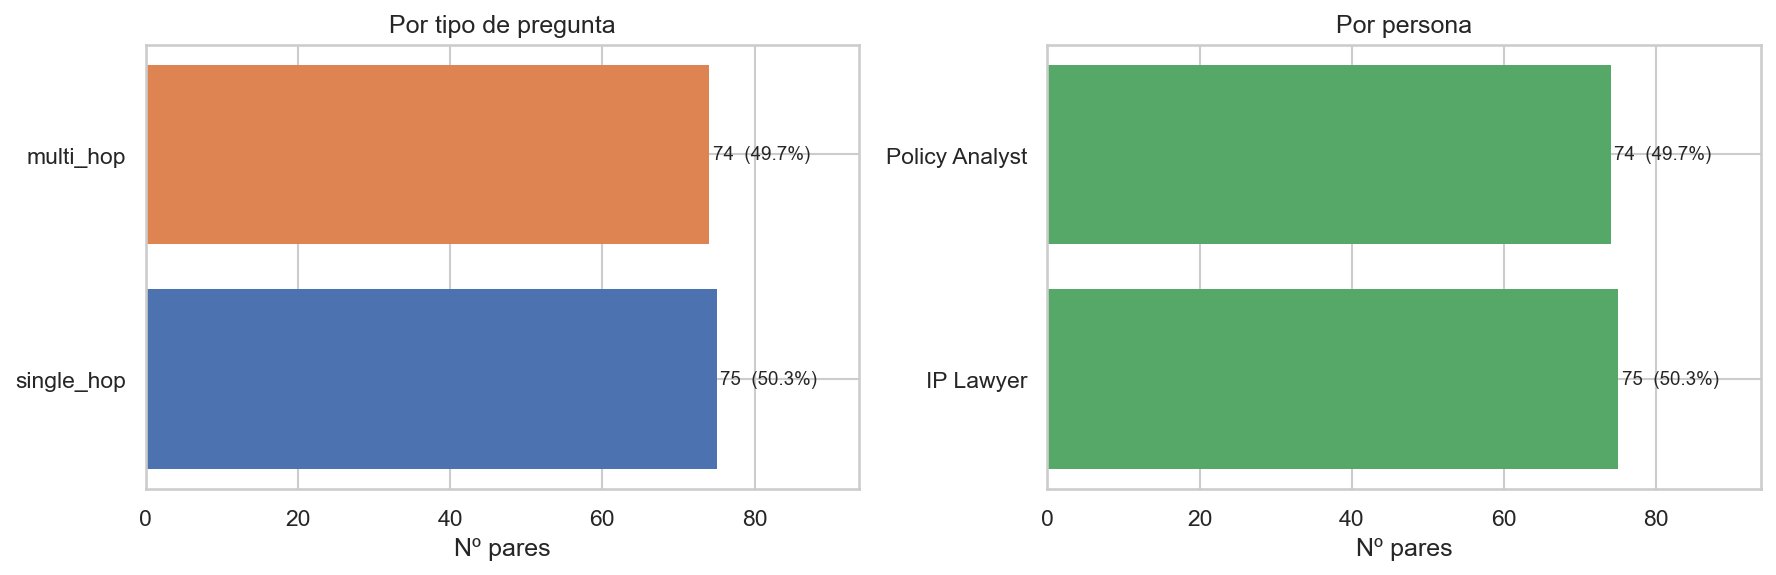

persona_name,IP Lawyer,Policy Analyst
synth,,
multi_hop,33,41
single_hop,42,33


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Synthesizer
ax = axes[0]
counts = df['synth'].value_counts()
bars = ax.barh(counts.index, counts.values,
               color=[SYNTH_COLORS[s] for s in counts.index], edgecolor='none')
for bar, val in zip(bars, counts.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}  ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Nº pares')
ax.set_title('Por tipo de pregunta')
ax.set_xlim(0, counts.max() * 1.25)

# Persona
ax2 = axes[1]
pcounts = df['persona_name'].value_counts()
ax2.barh(pcounts.index, pcounts.values, color='#55A868', edgecolor='none')
for bar, val in zip(ax2.patches, pcounts.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}  ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax2.set_xlabel('Nº pares')
ax2.set_title('Por persona')
ax2.set_xlim(0, pcounts.max() * 1.25)

plt.tight_layout()
plt.savefig(FIGURES / 'gold_synth_persona.pdf')
plt.savefig(FIGURES / 'gold_synth_persona.png')
plt.show()

dist = df.groupby(['synth','persona_name']).size().unstack(fill_value=0)
display(dist)
dist.to_csv(TABLES / 'gold_synth_persona.csv')

## 3. Estilo e lonxitude das preguntas

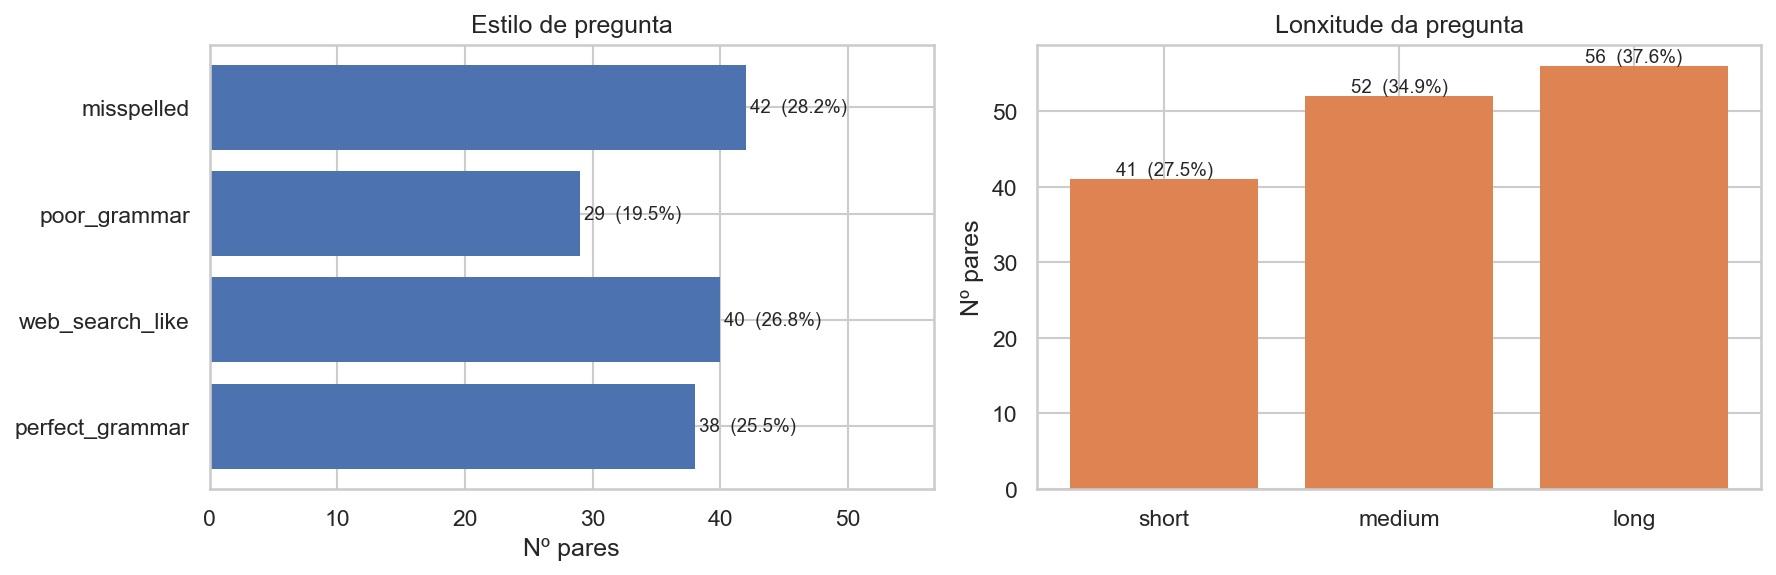

query_length,long,medium,short
query_style,,,
misspelled,16,14,12
perfect_grammar,12,16,10
poor_grammar,13,6,10
web_search_like,15,16,9


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Estilo
ax = axes[0]
scounts = df['query_style'].value_counts().reindex(STYLE_ORDER).dropna()
ax.barh(scounts.index, scounts.values, color='#4C72B0', edgecolor='none')
for bar, val in zip(ax.patches, scounts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}  ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Nº pares')
ax.set_title('Estilo de pregunta')
ax.set_xlim(0, scounts.max() * 1.35)

# Lonxitude
ax2 = axes[1]
lcounts = df['query_length'].value_counts().reindex(LENGTH_ORDER).dropna()
ax2.bar(lcounts.index, lcounts.values, color='#DD8452', edgecolor='none')
for bar, val in zip(ax2.patches, lcounts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val}  ({val/len(df)*100:.1f}%)', ha='center', fontsize=9)
ax2.set_ylabel('Nº pares')
ax2.set_title('Lonxitude da pregunta')

plt.tight_layout()
plt.savefig(FIGURES / 'gold_style_length.pdf')
plt.savefig(FIGURES / 'gold_style_length.png')
plt.show()

style_len = df.groupby(['query_style','query_length']).size().unstack(fill_value=0)
display(style_len)
style_len.to_csv(TABLES / 'gold_style_length.csv')

## 4. Lonxitude das respostas e contextos de referencia

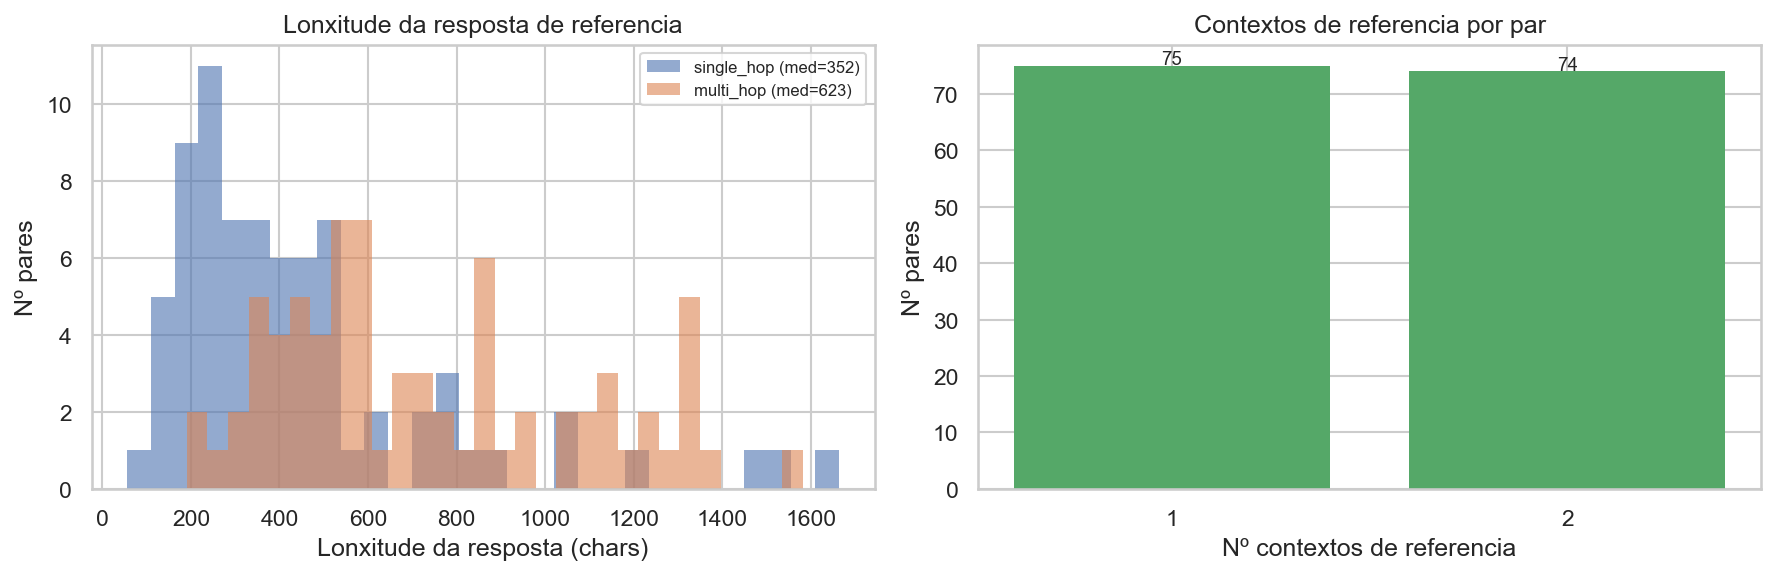

,n,mediana_resposta,media_resposta,mediana_contextos
synth,,,,
multi_hop,74,624,733,2
single_hop,75,352,450,1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Lonxitude da resposta por tipo
ax = axes[0]
for synth, color in SYNTH_COLORS.items():
    vals = df[df['synth'] == synth]['ref_len']
    ax.hist(vals, bins=30, alpha=0.6, color=color,
            label=f'{synth} (med={int(vals.median())})', edgecolor='none')
ax.set_xlabel('Lonxitude da resposta (chars)')
ax.set_ylabel('Nº pares')
ax.set_title('Lonxitude da resposta de referencia')
ax.legend(fontsize=8)

# Número de contextos de referencia
ax2 = axes[1]
ctx_counts = df['n_ref_contexts'].value_counts().sort_index()
ax2.bar(ctx_counts.index.astype(str), ctx_counts.values, color='#55A868', edgecolor='none')
for bar, val in zip(ax2.patches, ctx_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             str(val), ha='center', fontsize=9)
ax2.set_xlabel('Nº contextos de referencia')
ax2.set_ylabel('Nº pares')
ax2.set_title('Contextos de referencia por par')

plt.tight_layout()
plt.savefig(FIGURES / 'gold_ref_lengths.pdf')
plt.savefig(FIGURES / 'gold_ref_lengths.png')
plt.show()

ref_stats = df.groupby('synth').agg(
    n=('ref_len', 'count'),
    mediana_resposta=('ref_len', 'median'),
    media_resposta=('ref_len', 'mean'),
    mediana_contextos=('n_ref_contexts', 'median'),
).round(0).astype(int)
display(ref_stats)
ref_stats.to_csv(TABLES / 'gold_ref_stats.csv')

## 5. Mostras de preguntas por tipo

In [6]:
for synth in ['single_hop', 'multi_hop']:
    sample = df[df['synth'] == synth].sample(2, random_state=42)
    print(f"{'='*70}")
    print(f"TIPO: {synth}")
    for _, row in sample.iterrows():
        print(f"  Persona : {row['persona_name']}  |  Estilo: {row['query_style']}  |  Lonx: {row['query_length']}")
        print(f"  Q: {row['user_input']}")
        ref_preview = row['reference'][:300]
        print(f"  A: {ref_preview}{'...' if len(row['reference']) > 300 else ''}")
        print()

TIPO: single_hop
  Persona : IP Lawyer  |  Estilo: misspelled  |  Lonx: short
  Q: What is the Counsil's role in copyright directives?
  A: The European Parliament and Council issue directives on copyright and related rights, as referenced in the context.

  Persona : IP Lawyer  |  Estilo: misspelled  |  Lonx: medium
  Q: Under Directiv (EU) 2017/1564, what are the rules for exportin accessible format copies to third countres?
  A: An authorised entity established in a Member State may distribute, communicate or make available to beneficiary persons or to an authorised entity established in a third country that is a party to the Marrakesh Treaty an accessible format copy of a work or other subject matter made in accordance wit...

TIPO: multi_hop
  Persona : Policy Analyst  |  Estilo: misspelled  |  Lonx: medium
  Q: How does Articel 5(3) of Counsil Regulashun 44/2001 relate to the fair compensashun system in Direktiv 2001/29, and how does that connecct to the ISP blockin injunsion dis